In [1]:
import gdown
file_url = "https://drive.google.com/uc?id=1AEheyDLh3oQcW4gBtG7aRsZCRie6Z3xW"
data_path = '/content/Fig1_data_20251115.xlsx'
gdown.download(file_url, data_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1AEheyDLh3oQcW4gBtG7aRsZCRie6Z3xW
To: /content/Fig1_data_20251115.xlsx
100%|██████████| 115k/115k [00:00<00:00, 37.1MB/s]


'/content/Fig1_data_20251115.xlsx'

In [2]:
import pandas as pd

# Read the Excel file, skipping the first two rows
df = pd.read_excel(data_path, sheet_name='Table 1 Visualization', skiprows=2)

# Skip the first column by selecting all columns from the second one onwards
df = df.iloc[:, 1:]

# Fill NaN values with the latest non-NaN value above
df_filled = df.ffill()

modify_columns = ['Ia', 'Ib', 'Ic', 'II', 'IIIa.1', 'IIIa.2', 'IIIa.3', 'IIIb']

for mc in modify_columns:
  new_list = []
  for dfI in df_filled[mc].values:
    try:
      if '/' in dfI:
        new_list.append(1)
    except:
      new_list.append(dfI)

  df_filled[mc] = new_list

# Display the first 5 rows of the DataFrame with filled values
display(df_filled.head())

,Unnamed: 1,InterproScan ID,Existence in HTCC1062,Ia,Ib,Ic,II,IIIa.1,IIIa.2,IIIa.3,IIIb,Bacteria,Pseudomonadota,Alphaproteobacteria,SAR11,References
0,DnaA,IPR013159,1,0.932039,0.911565,1.0,0.951220,1,0.333333,0.888889,0.909091,45945,15614,6479,118,NaN
1,DnaA,IPR020591,1,0.936893,0.904762,1.0,0.939024,1,0.333333,0.888889,0.909091,46580,15726,4958,116,NaN
2,DnaA,IPR013317,1,0.936893,0.904762,1.0,0.939024,1,0.333333,0.888889,0.909091,50897,19686,5087,118,NaN
3,DnaA,IPR038454,1,0.927184,0.857143,1.0,0.939024,1,0.333333,0.888889,0.909091,40428,14054,5328,120,NaN
4,DnaA,IPR024633,1,0.927184,0.850340,1.0,0.939024,1,0.333333,0.888889,0.909091,33757,13994,5320,118,NaN


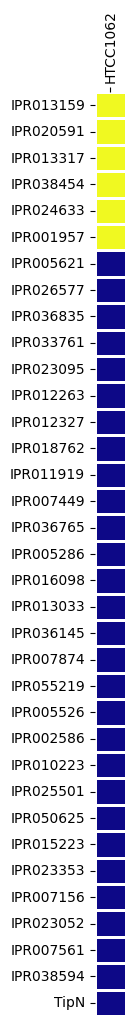

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the specific column
heatmap_data = df_filled[['Existence in HTCC1062']]

# Create the heatmap, setting yticklabels to 'InterproScan ID'
plt.figure(figsize=(0.4, 12))
sns.heatmap(heatmap_data, cmap='plasma', cbar=False, yticklabels=df_filled['InterproScan ID'].values, linewidths=1)
#plt.title('Heatmap of Existence in HTCC1062 by InterproScan ID')
#plt.ylabel('InterproScan ID')
plt.yticks(rotation=0)

# Move x-axis ticks to the top
plt.tick_params(axis='x', labeltop=True, labelbottom=False, top=True, bottom=False)
plt.xticks([0.5], ['HTCC1062'], rotation=90) # Keep rotation if needed for readability

plt.savefig('/content/HTCC1062_heatmap.pdf')
plt.show()

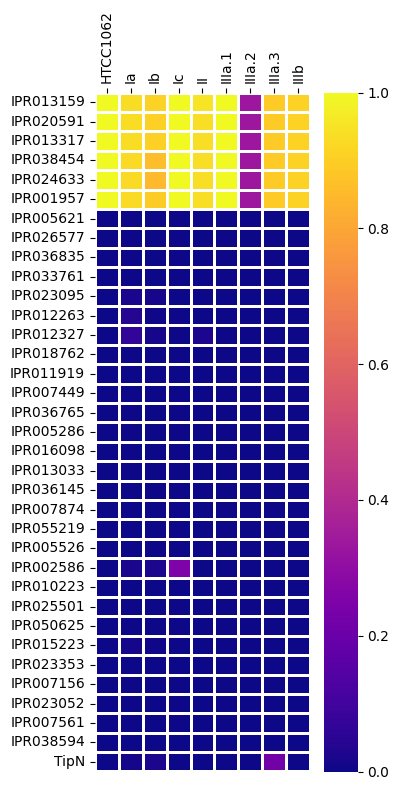

In [4]:
# Select the specific column
heatmap_data = df_filled[['Existence in HTCC1062', 'Ia', 'Ib', 'Ic', 'II', 'IIIa.1', 'IIIa.2', 'IIIa.3', 'IIIb']]

# Create the heatmap, setting yticklabels to 'InterproScan ID'
plt.figure(figsize=(4, 8))
sns.heatmap(heatmap_data, cmap='plasma', cbar=True, cbar_kws=dict(use_gridspec=True,
                                                                  location="right", orientation="vertical"),
            yticklabels=df_filled['InterproScan ID'].values, linewidths=1)
#plt.title('Heatmap of Existence in HTCC1062 by InterproScan ID')
#plt.ylabel('InterproScan ID')
plt.yticks(rotation=0)

# Move x-axis ticks to the top
plt.tick_params(axis='x', labeltop=True, labelbottom=False, top=True, bottom=False)
plt.xticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5],
           ['HTCC1062', 'Ia', 'Ib', 'Ic', 'II', 'IIIa.1', 'IIIa.2', 'IIIa.3', 'IIIb'],
           rotation=90) # Keep rotation if needed for readability

plt.tight_layout()
plt.savefig('/content/Fig1_heatmap_1.pdf')
plt.show()

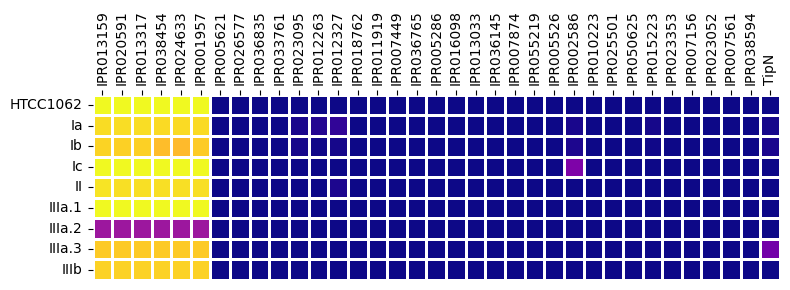

In [5]:
# Select the specific column
heatmap_data = df_filled[['Existence in HTCC1062', 'Ia', 'Ib', 'Ic', 'II', 'IIIa.1', 'IIIa.2', 'IIIa.3', 'IIIb']]

# Create the heatmap, setting yticklabels to 'InterproScan ID'
plt.figure(figsize=(8, 3))
sns.heatmap(heatmap_data.T, cmap='plasma', cbar=False, cbar_kws=dict(use_gridspec=True,
                                                                  location="right", orientation="vertical"),
            xticklabels=df_filled['InterproScan ID'].values, linewidths=1)
#plt.title('Heatmap of Existence in HTCC1062 by InterproScan ID')
#plt.ylabel('InterproScan ID')


plt.yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5],
           ['HTCC1062', 'Ia', 'Ib', 'Ic', 'II', 'IIIa.1', 'IIIa.2', 'IIIa.3', 'IIIb'],
           rotation=0) # Keep rotation if needed for readability

# Move x-axis ticks to the top
plt.tick_params(axis='x', labeltop=True, labelbottom=False, top=True, bottom=False)
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig('/content/Fig1_heatmap_2.pdf')
plt.show()

In [6]:
df_filled[['Bacteria','Pseudomonadota','Alphaproteobacteria','SAR11']]

,Bacteria,Pseudomonadota,Alphaproteobacteria,SAR11
0,45945,15614,6479,118
1,46580,15726,4958,116
2,50897,19686,5087,118
3,40428,14054,5328,120
4,33757,13994,5320,118
5,40129,13489,4667,113
6,2152,2138,0,0
7,2256,2212,1,0
8,2430,2254,24,0
9,2243,2206,10,0


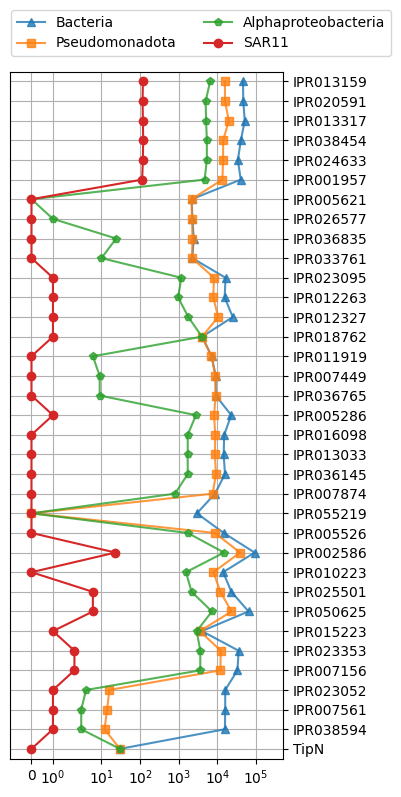

In [7]:
fig, axs = plt.subplots(figsize = (4,8))

axs.plot(df_filled['Bacteria'][::-1], df_filled.index, '^-', alpha=0.8, label='Bacteria')
axs.plot(df_filled['Pseudomonadota'][::-1], df_filled.index, 's-', alpha=0.8, label='Pseudomonadota')
axs.plot(df_filled['Alphaproteobacteria'][::-1], df_filled.index, 'p-', alpha=0.8, label='Alphaproteobacteria')
axs.plot(df_filled['SAR11'][::-1], df_filled.index, 'o-', label = 'SAR11')

axs.set_yticks(df_filled.index)
axs.set_yticklabels(df_filled['InterproScan ID'].values[::-1])
axs.set_xscale('symlog')

axs.tick_params(axis='y', labelright=True, labelleft=False, right=True, left=False)

axs.set_xlim(-1, 5e5)
axs.set_ylim(-0.5,34.5)

axs.grid('on')
axs.legend(loc='upper center', bbox_to_anchor=(0.7, 1.1), ncol=2)
fig.tight_layout()

fig.savefig('/content/Fig1_Line_plot.pdf')
fig.show()

In [8]:
visualization_2 = df_filled[['Bacteria','Pseudomonadota','Alphaproteobacteria','SAR11']]
visualization_2 = visualization_2/(visualization_2.loc[[0,1,2,3,4,5]].max(axis=0))
visualization_2[visualization_2<0.01]=0
visualization_2[visualization_2>=0.1]=1
visualization_2[(visualization_2>=0.01) & (visualization_2<0.1)]=0.5

data = visualization_2.T.values
rows, cols = data.shape
col_labels = df_filled['InterproScan ID'].values
row_labels = visualization_2.columns.tolist()

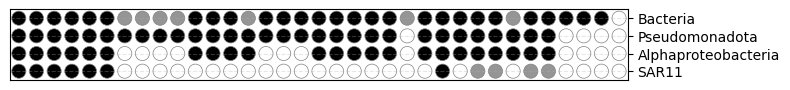

In [9]:
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
import numpy as np

cmap='Greys'
circle_size=0.4

fig, ax = plt.subplots(figsize=(8,4))

# Create circles for each cell
circles = []
colors = []

for i in range(rows):
    for j in range(cols):
        circle = Circle((j, rows - 1 - i), circle_size)
        circles.append(circle)
        colors.append(data[i, j])

# Create collection of circles
collection = PatchCollection(circles, cmap=cmap, edgecolors='gray', linewidths=0.5)
collection.set_array(np.array(colors))
collection.set_clim(vmin=0, vmax=1)  # Set color limits for values 0 to 1

ax.add_collection(collection)

# Set axis properties
ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_aspect('equal')

# Add gridlines and labels from DataFrame
#ax.set_xticks(range(cols))
ax.set_xticks([])
ax.set_yticks(range(rows))
#ax.set_xticklabels(col_labels, rotation=45, ha='right')
ax.set_yticklabels(row_labels[::-1])  # Reverse to match data orientation
ax.grid(True, alpha=0.3, linestyle='--')

# Add colorbar
#cbar = plt.colorbar(collection, ax=ax, fraction=0.046, pad=0.04)
#cbar.set_label('Value', rotation=270, labelpad=20)

#ax.xaxis.tick_top()
#ax.xaxis.set_label_position('top')
#ax.set_xticklabels(col_labels, rotation=45, ha='left')

ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

# Labels
#ax.set_xlabel('Column')
#ax.set_ylabel('Row')
#ax.set_title('Circular Heatmap', fontsize=14, fontweight='bold')
fig.savefig('/content/Fig1_circle_plot.pdf')
fig.tight_layout()